# **Project:** Student perfomance Algorithm

**Dataset:** UCI Student Performance Dataset (Cortez & Silva, 2008) Real data from 395 secondary school students in Portugal. Source: https://archive.ics.uci.edu/dataset/320/student+performance

**Tutorial by:** [DIRISA](https://www.dirisa.ac.za/) Student Datathon, Intro to Stats & Algorithms

**Details:** Building an algorithm that uses real student data to predict student perfomances. We will visualise the decesion tree and make a prediction.

**Technology:**

* Python
* Pandas
* Matplotlib
* Google colab

# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import export_text

Import student data

Install ucimlrepo

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets

# metadata
print(student_performance.metadata)

# variable information
print(student_performance.variables)


{'uci_id': 320, 'name': 'Student Performance', 'repository_url': 'https://archive.ics.uci.edu/dataset/320/student+performance', 'data_url': 'https://archive.ics.uci.edu/static/public/320/data.csv', 'abstract': 'Predict student performance in secondary education (high school). ', 'area': 'Social Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 649, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': ['Sex', 'Age', 'Other', 'Education Level', 'Occupation'], 'target_col': ['G1', 'G2', 'G3'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2008, 'last_updated': 'Fri Jan 05 2024', 'dataset_doi': '10.24432/C5TG7T', 'creators': ['Paulo Cortez'], 'intro_paper': {'ID': 360, 'type': 'NATIVE', 'title': 'Using data mining to predict secondary school student performance', 'authors': 'P. Cortez, A. M. G. Silva', 'venue': 'Proceedings of 5th Annual Future Business Technolo

# Data cleaning & sorting

Cleaning and sorting the data into desired dataset.

In [ ]:
combined_df = pd.concat([X, y], axis=1)
df = combined_df[['studytime', 'G1', 'absences', 'G3']].copy()
df.columns = ['studytime', 'prev_grade', 'absences', 'final_grade']
df.head(n=3)

,studytime,prev_grade,absences,final_grade
0,2,0,4,11
1,2,9,2,11
2,2,12,6,12


In [ ]:
#Creating a target variable. Pass (1) if final grade >=10, Fail (0) otherwise
df['results'] = (df['final_grade'] >= 10).astype(int)
df = df.drop(columns=['final_grade'])

df.head()

,studytime,prev_grade,absences,results
0,2,0,4,1
1,2,9,2,1
2,2,12,6,1
3,3,14,0,1
4,2,11,0,1


# Training a single Decision Tree

The max_depth will be 3 so the tree stays readable. This will help avoid the tree from memorising the training data.

In [ ]:
x = df[['studytime','prev_grade', 'absences']]
y = df['results']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=42)
tree = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)

tree.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

Check the Tranning accuracy and the test accuracy

In [ ]:
train_acc = accuracy_score(y_train, tree.predict(x_train))
test_acc = accuracy_score(y_test, tree.predict(x_test))

print(f'Train Accuracy: {train_acc:.1%}')
print(f'Test Accuracy: {test_acc:.1%}')

Train Accuracy: 92.5%
Test Accuracy: 91.5%


# Visualise the decesion tree

Visualise the structure of the algorithm learned from 316 students. Each node shows the question it asks, the Gini impurity, and how many students landed there. Trace a path from the root to a leaf.

[Text(0.5, 0.875, 'prev_grade <= 9.5\nentropy = 0.643\nsamples = 519\nvalue = [85, 434]'),
 Text(0.25, 0.625, 'prev_grade <= 8.5\nentropy = 0.975\nsamples = 130\nvalue = [77, 53]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'prev_grade <= 7.5\nentropy = 0.742\nsamples = 76\nvalue = [60, 16]'),
 Text(0.0625, 0.125, 'entropy = 0.519\nsamples = 43\nvalue = [38, 5]'),
 Text(0.1875, 0.125, 'entropy = 0.918\nsamples = 33\nvalue = [22, 11]'),
 Text(0.375, 0.375, 'absences <= 21.5\nentropy = 0.899\nsamples = 54\nvalue = [17, 37]'),
 Text(0.3125, 0.125, 'entropy = 0.867\nsamples = 52\nvalue = [15.0, 37.0]'),
 Text(0.4375, 0.125, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.625, 'prev_grade <= 10.5\nentropy = 0.145\nsamples = 389\nvalue = [8.0, 381.0]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'absences <= 5.0\nentropy = 0.424\nsamples = 81\nvalue = [7, 74]'),
 Text(0.5625, 0.125, 'entropy = 0.537\nsamples = 57\nvalue = [7, 50]'),
 Text(0.6875, 0.125, 'entropy 

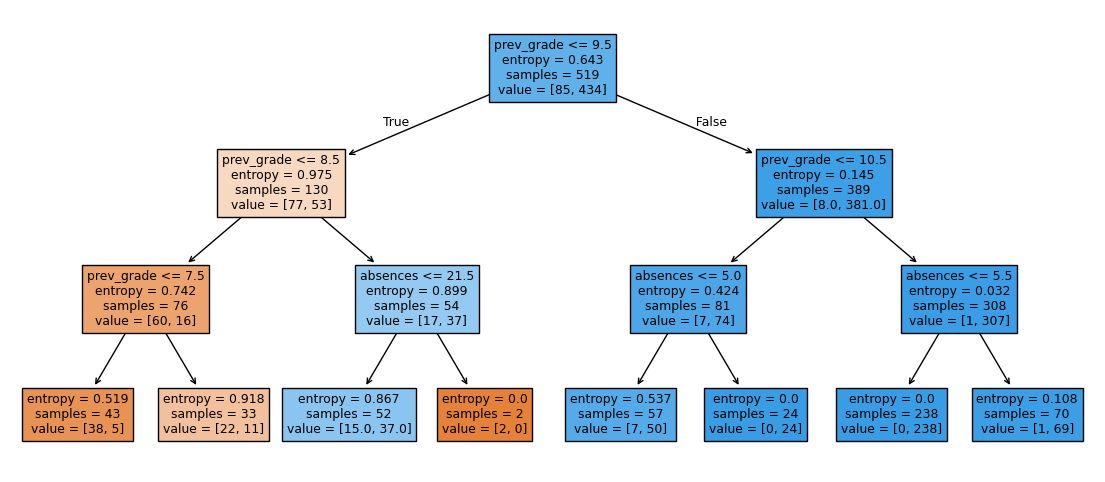

In [ ]:
#Draw the tree using matplotlib
fig, ax = plt.subplots(figsize=(14,6))
plot_tree(tree, ax=ax, feature_names=x.columns, filled=True)

Tree as rules

*Use sklearn to print the tree as a set of if/else rules.*

In [ ]:
r = export_text(tree, feature_names=x.columns.tolist())
print(r)

|--- prev_grade <= 9.50
|   |--- prev_grade <= 8.50
|   |   |--- prev_grade <= 7.50
|   |   |   |--- class: 0
|   |   |--- prev_grade >  7.50
|   |   |   |--- class: 0
|   |--- prev_grade >  8.50
|   |   |--- absences <= 21.50
|   |   |   |--- class: 1
|   |   |--- absences >  21.50
|   |   |   |--- class: 0
|--- prev_grade >  9.50
|   |--- prev_grade <= 10.50
|   |   |--- absences <= 5.00
|   |   |   |--- class: 1
|   |   |--- absences >  5.00
|   |   |   |--- class: 1
|   |--- prev_grade >  10.50
|   |   |--- absences <= 5.50
|   |   |   |--- class: 1
|   |   |--- absences >  5.50
|   |   |   |--- class: 1



# New student prediction


In [ ]:
#Collect new student data from user

studytime_input = int(input("Enter study time (1-4, where 1: <2 hours, 2: 2-5 hours, 3: 5-10 hours, 4: >10 hours): "))
prev_grade_input = int(input("Enter previous grade (0-20): "))
absences_input = int(input("Enter number of absences: "))

new_student_data = {'studytime': [studytime_input], 'prev_grade': [prev_grade_input], 'absences': [absences_input]}
new_student_df = pd.DataFrame(new_student_data)

prediction = tree.predict(new_student_df)

if prediction[0] == 1:
    print("Prediction for new student: Pass")
else:
    print("Prediction for new student: Fail")

Enter study time (1-4, where 1: <2 hours, 2: 2-5 hours, 3: 5-10 hours, 4: >10 hours): 1
Enter previous grade (0-20): 10
Enter number of absences: 3
Prediction for new student: Pass


# Random Forest

A single Decision Tree is unstable. Train it on slightly different data and the tree changes significantly.

**Random Forest** fixes this by training 100 trees, each on a random sample of the data and a random subset of features. The majority vote wins.

In [ ]:
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(x_train, y_train)

forest_train_acc = accuracy_score(y_train, forest.predict(x_train))
forest_test_acc = accuracy_score(y_test, forest.predict(x_test))

print(f'Random Forest Train Accuracy: {forest_train_acc:.1%}')
print(f'Random Forest Test Accuracy: {forest_test_acc:.1%}')

Random Forest Train Accuracy: 95.4%
Random Forest Test Accuracy: 90.8%


Test which feature matters the most

In [ ]:
feature_importances = pd.Series(forest.feature_importances_, index=x_train.columns)
print(feature_importances.sort_values(ascending=False))

prev_grade    0.735719
absences      0.212798
studytime     0.051483
dtype: float64


Visulise the feature importances

Text(0.5, 0, 'Feature')

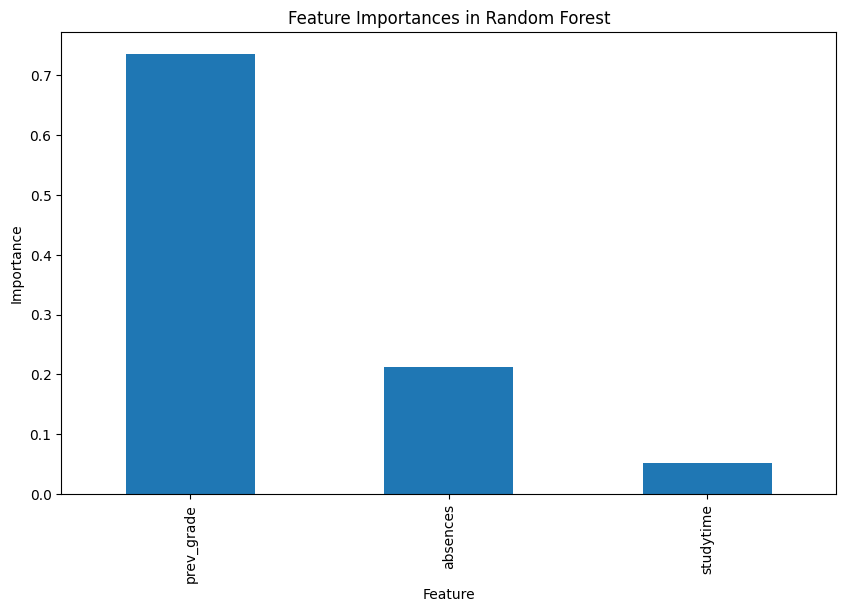

In [ ]:
plt.figure(figsize=(10, 6))
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importances in Random Forest')
plt.ylabel('Importance')
plt.xlabel('Feature')